In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
import seaborn as snb
from typing import NamedTuple
from typing import Tuple

from scipy.stats import binom as binom_dist
from scipy.stats import beta as beta_dist
from scipy.special import beta as beta_fun

snb.set_style('darkgrid')
snb.set(font_scale=1.5)
plt.rcParams['lines.linewidth'] = 3


# Assignment 1 - 02477 Bayesian Machine Learning

Date: 02/03/2026

Bella Strandfort (s214215) & Sofie Ullum Jensen (s224185)

## Part 1 - The beta-binomial model

We have the following know parameters:
$$N = 115 \qquad y = 4 \qquad \theta\in [0,1] \qquad  N^* = 20  \qquad   y^* = ?$$
And the models:
\begin{align*}
\theta & \sim \text{Beta}(a_0, b_0) \qquad \text{where} \quad a_0=b_0=1\\
y|\theta & \sim \text{Binomial}(N,\theta)
\end{align*}

In [3]:
N = 115
y = 4
N_s = 20
a0 = 1
b0 = 1

### Task 1.1 Prior mean and 95%-credibility interval
$$\mathbb{E}\left[\theta\right]  = \frac{a_0}{a_0+b_0} = \frac{1}{2}$$

Since a beta distribution with both parameters equal to 1, corresponds to a uniform distribution over the interval [0,1], a 95% credibility interval is just [0.025, 0.975]

### Task 1.2 Posterior mean and 95%-credibility interval

We know that the posterior of theta is another beta distribution given by:
$$ p(\theta|y) = \text{Beta}(\theta|a_0 + y, b_0 + N-y) $$

Therfore the posterior mean is:
$$E_{p(\theta|y)} = \frac{a_0 + y}{a_0 + b_0 + N} = \frac{1 + 4}{1 + 1 + 115 } = \frac{5}{117}$$

For the credibility interval, we will use the Beta distribtution defined in exercise 1:

In [4]:
class BetaDistribution(NamedTuple):
    a:  int
    b:  int

    def pdf(self, theta):
        """ returns Beta(theta|a,b) """
        return beta_dist.pdf(theta, a=self.a, b=self.b)
    
    @property
    def mean(self):
        """ returns mean of Beta(a,b)-distribution """
        return self.a/(self.a + self.b)
    
    @property
    def variance(self):
        """ returns variance of Beta(a,b)-distribution """
        return self.a*self.b/(self.a + self.b)**2/(self.a + self.b + 1)
    
    @property
    def mode(self):
        """ returns mode of Beta(a,b)-distribution (assuming it exists) """
        return (self.a - 1)/(self.a+self.b-2)
    
    def get_interval(self, interval_size):
        """ returns a tuple representing a interval_size% credibility interval of Beta(a,b) using scipy.stats.beta.interval  """
        return beta_dist.interval(interval_size/100, a=self.a, b=self.b)
    
    def sample(self, num_samples):
        return beta_dist.rvs(a=self.a, b=self.b, size=num_samples)

In [5]:
prior = BetaDistribution(a=a0, b=b0)
posterior = BetaDistribution(prior.a + y, prior.b + N - y)

posterior.get_interval(95)

(np.float64(0.01414155664664075), np.float64(0.08593831005795628))

From the Beta distribtion class, we get that the $95%$-credibility interval is $[0.014,0.086]$

### Task 1.3 Posterior predictive distribution

In the plot below, we see the posterior predictive distribution for $y*$ given $y=4$

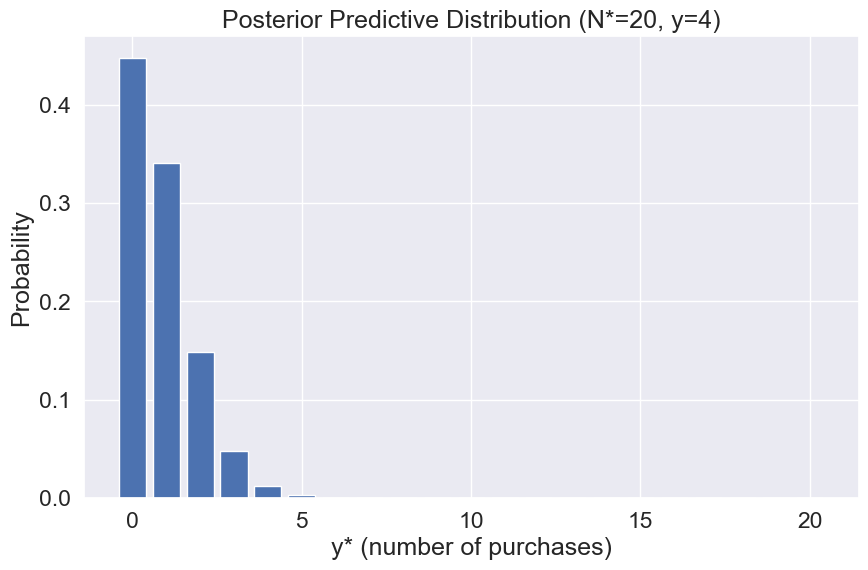

In [16]:
# Sample from posterior
num_samples = 10000
theta_samples = posterior.sample(num_samples)

y_s = jnp.arange(0, N_s + 1)

ppd = jnp.array([
    jnp.mean(binom_dist.pmf(k, N_s, theta_samples))
    for k in y_s
])


ppd = ppd / jnp.sum(ppd)

# Plot it
plt.figure(figsize=(10, 6))
plt.bar(y_s, ppd)
plt.xlabel('y* (number of purchases)')
plt.ylabel('Probability')
plt.title(f'Posterior Predictive Distribution (N*={N_s}, y={y})')
plt.show()

### Task 1.4 Posterior predictive probability for $N^*=20$

To find the probability, that at least one of the next $N^*=20$ customers will make a purchase, we must sum the probabilities, for $y^* \geq 1$

In [22]:
prob_at_least_one = jnp.sum(ppd[1:])
prob_at_least_one

Array(0.55286986, dtype=float32)

This gives that there is a $55.29\%$ chance that at least one of the next 20 customers will make a purchase

### Task 1.5 Mean and variance of the posterior predictive distribution

Since the posterior predictive distribution follows a Beta distribution, we get that the mean is

$$
\mathbb{E}[y^*|y] = N^* \mathbb{E}[\theta|y] = 20 \cdot \frac{5}{117} = \frac{100}{117}
$$

and the variance is 

$$
\text{Var}[y^*|y]=N^* \frac{\alpha\beta}{(\alpha+\beta)^2} \frac{\alpha+\beta+N^*}{\alpha+\beta+1} = 20 \frac{560}{(5+112)^2} \frac{5+112+20}{5+112+1}= \frac{1534400}{1615302}\approx 0.95
$$

## Part 2: Linear Gaussian System

### Task 2.1 Determine $p(y)$

$p(y)$

### Task 2.2 Determine $p(y,z_2|z_1)$

### Task 2.3 Determine $p(y|z_1)$

### Task 2.4 Determine $p(z_1|y)$

## Part 3 Conjugate model for count data

In this exercise we have the following model

\begin{align*}
y_i|\lambda &\sim \text{Poisson}(\lambda)\\
\lambda &\sim \text{Gamma}(a_0,b_0)
\end{align*}

where the probability mass function for the Poisson distribution is
$$
p(y_i|\lambda) = \frac{\lambda^{y_i}e^{-\lambda}}{y_i!}
$$

and the probability density function for the Gamma distribution is
$$
p(\lambda|a_0,b_0)=\frac{b_0^{a_0}}{\Gamma(a_0)}\lambda^{a_0-1}e^{-b_0\lambda}
$$

### Task 3.1 Determine the joint distribution

Using the prior and likelihood given in the description, the joint distribution becomes

$$\begin{align*}
p(y,\lambda)=p(y|\lambda)p(\lambda|a_0,b_0)&=\frac{1}{y!}\lambda^{y}e^{-\lambda}\frac{b_0^{a_0}}{\Gamma(a_0)\lambda^{a_0-1}e^{-b_0\lambda}}\\
&=\frac{b_0^{a_0}}{y!\Gamma(a_0)}\lambda^{y+a_0-1}e^{(1-b_0)\lambda}
\end{align*}$$

### Task 3.2 Functional form of a Gamma distribution

In order to show that the functional form of a Gamma distribution is given by $\log p(\lambda|a,b)=(a-1)\lambda - b\lambda + \text{constant}$, we must apply $log$ to the pdf of the Gamma distribution

$$
\log(p(\lambda|a,b))=\log \frac{b^a}{ \Gamma(a)}\lambda^{a-1}e^{-b\lambda}
$$

Using the rules for logarithms we get
$$
= \log b^a - \log \Gamma(a) + (a-1)\log \lambda-b\lambda 
$$

Since $\log b^a$ and $\Gamma(a)$ are independent of $\lambda$, they are constant. And we therefore get

$$
=(a-1)\log(\lambda)-b\lambda+\text{constant}
$$

as the functional form of a Gamma distribution.

### Task 3.3 Posterior distribution $p(\lambda|y)$

In order to find the posterior distribution $p(\lambda|y)$, we must use Bayes rule, which states that

$$\begin{align*}
p(\lambda|y)=\frac{p(y|\lambda)p(\lambda|a_0,b_0)}{p(y)}=\frac{p(y|\lambda)p(\lambda|a_0,b_0)}{\int p(y|\lambda')p(\lambda'|a_0,b_0)d\lambda'}
\end{align*}$$

Here we can see that, we have the joint distribution we found in 3.1 in both the numerator and denominator, which gives

$$\begin{align*}
p(\lambda|y)=\frac{\frac{b_0^{a_0}}{y!\Gamma(a_0)}\lambda^{y+a_0-1}e^{(1-b_0)\lambda}}{\int \frac{b_0^{a_0}}{y!\Gamma(a_0)}\lambda'^{y+a_0-1}e^{(1-b_0)\lambda'} d\lambda'}
\end{align*}$$

Deriving the integral in the denominator we get
$$\begin{align*}
\int \frac{b_0^{a_0}}{y!\Gamma(a_0)}\lambda'^{y+a_0-1}e^{(1-b_0)\lambda'} d\lambda'= \frac{\Gamma(y+a)b^a}{y!\Gamma(a)(1+b)^{y+a}}
\end{align*}$$

This is constant with regards to $\lambda$, which  means that the posterior is proportional to the joint distribution
$$\begin{align*}
p(\lambda|y)\propto\frac{b_0^{a_0}}{y!\Gamma(a_0)}\lambda^{y+a_0-1}e^{(1-b_0)\lambda}
\end{align*}$$

In order to show, that it is a Gamma distribution, we can now take log of the posterior

$$\begin{align*}
\log p(\lambda|y)&\propto
\log\frac{b_0^{a_0}}{y!\Gamma(a_0)}\lambda^{y+a_0-1}e^{(1-b_0)\lambda}\\
&= \log b_0^{a_0}-\log y! \Gamma(a_0) + (a_0-1)\log \lambda-b_0\lambda\\
&=(a_0-1)\log \lambda-b_0\lambda+\text{constant}
\end{align*}$$

This is the same as the functional form of a Gamma distribution, so the posterior must also be a Gamma distribution.

### Task 3.4 Posterior distribution for $\lambda$

### Task 3.5 Plot $p(\lambda)$ and $p(\lambda|y)$ for $\lambda\in[0,30]$